In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
gaia_path = '/global/cfs/cdirs/desi/users/rongpu/useful/gaia_edr3_g_14_pm_dr9.fits'
gaia = Table(fitsio.read(gaia_path))

In [4]:
tycho2 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/Tycho-2-dr9.fits'))

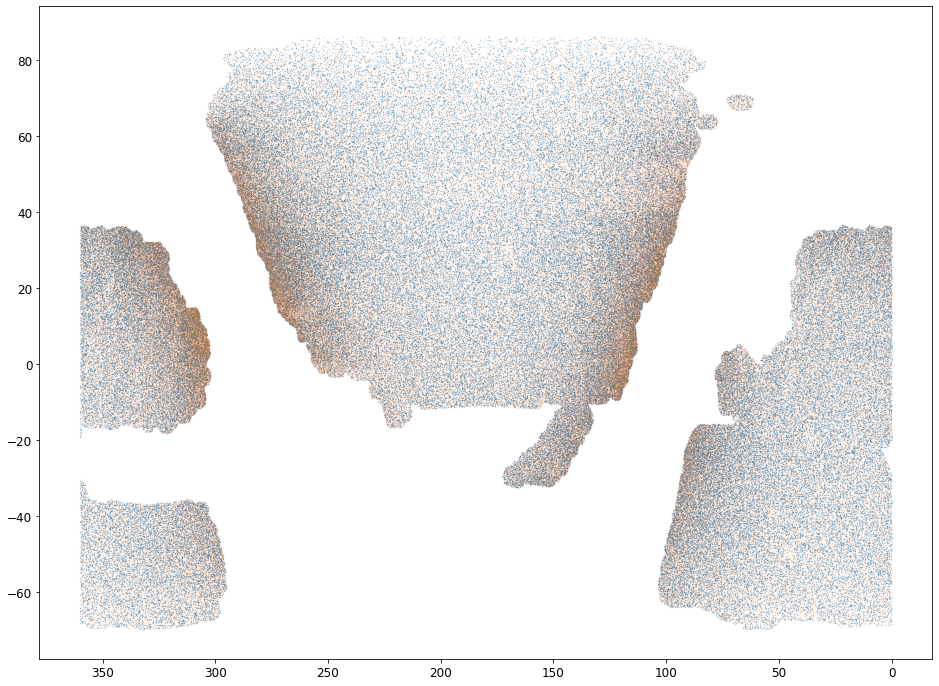

In [5]:
plt.figure(figsize=(16, 12))
plt.plot(tycho2['RA'][::5], tycho2['DEC'][::5], '.', ms=0.5, alpha=0.5)
plt.plot(gaia['RA'][::10], gaia['DEC'][::10], '.', ms=0.1, alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

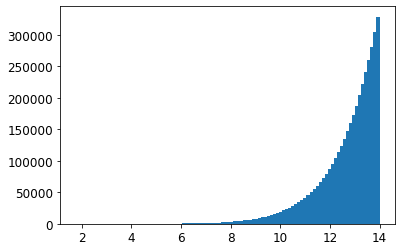

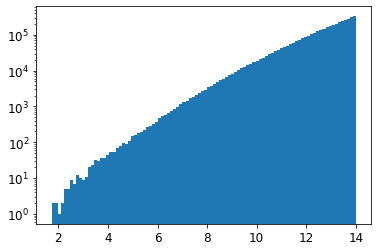

In [6]:
plt.hist(gaia['PHOT_G_MEAN_MAG'], 100)
plt.show()

plt.hist(gaia['PHOT_G_MEAN_MAG'], 100, log=True)
plt.show()

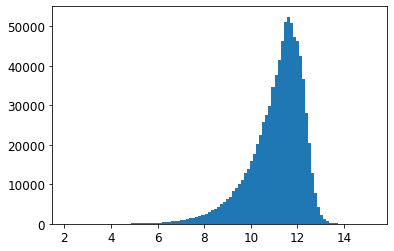

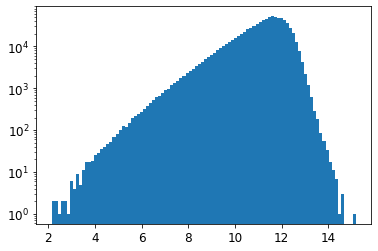

In [7]:
plt.hist(tycho2['VTmag'], 100)
plt.show()

plt.hist(tycho2['VTmag'], 100, log=True)
plt.show()

In [8]:
mask = gaia['PHOT_G_MEAN_MAG']<14
print(np.sum(mask)/len(mask))
gaia = gaia[mask]

1.0


In [9]:
mask = tycho2['VTmag']<10.
print(np.sum(mask)/len(mask))
tycho2 = tycho2[mask]

0.1489134550842469


In [10]:
gaia['RA2000'] = gaia['RA'] - 16 * gaia['PMRA'] * 1e-3/3600 / np.cos(np.radians(gaia['DEC']))
gaia['DEC2000'] = gaia['DEC'] - 16 * gaia['PMDEC'] * 1e-3/3600

Doubly matched objects = 353
Final matched objects = 124668


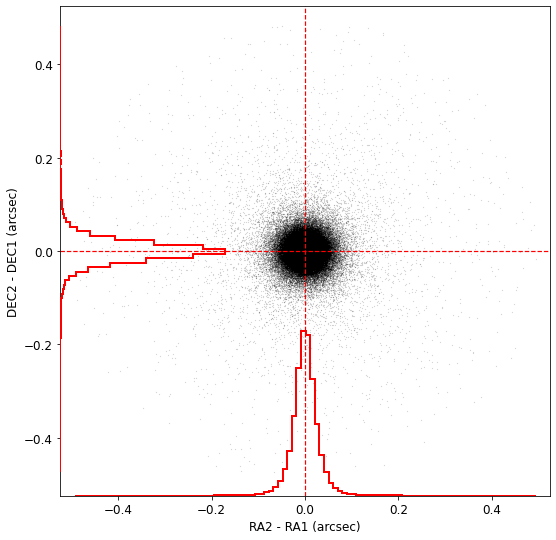

In [12]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import match_coord

idx1, idx2, d2d, d_ra, d_dec = match_coord(gaia['RA2000'], gaia['DEC2000'], tycho2['RA'], tycho2['DEC'], search_radius=0.5, plot_q=True)

In [14]:
print(len(idx1)/len(gaia))
print(len(idx1)/len(tycho2))

0.030939970233419725
0.987610114709424


In [15]:
gaia = gaia[idx1]
tycho2 = tycho2[idx2]

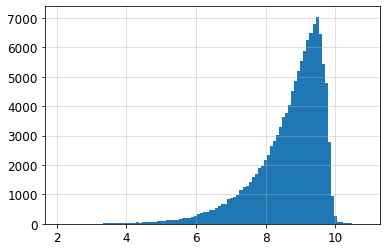

In [16]:
plt.hist(gaia['PHOT_G_MEAN_MAG'], 100)
plt.grid(alpha=0.5)

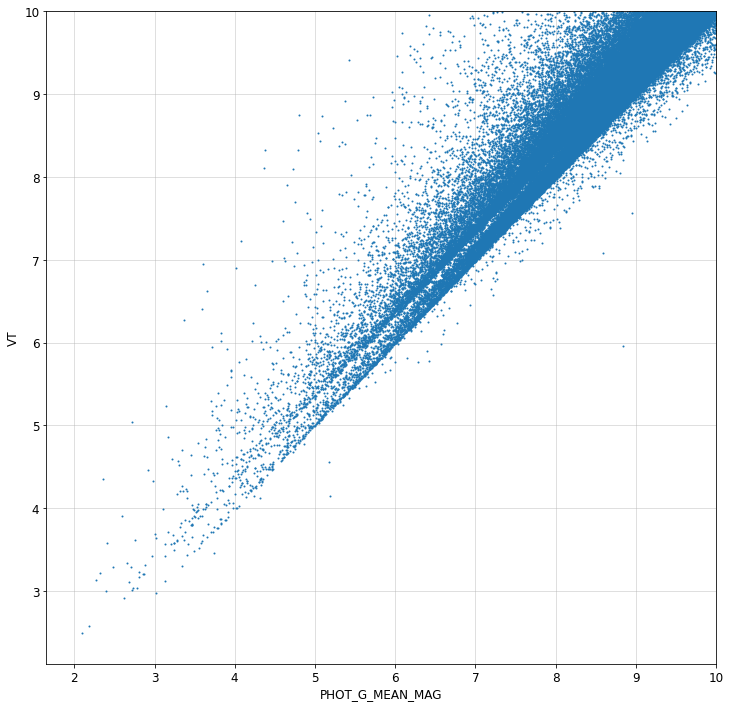

In [18]:
plt.figure(figsize=(12, 12))
plt.plot(gaia['PHOT_G_MEAN_MAG'], tycho2['VTmag'], '.', ms=2, alpha=1)
plt.xlabel('PHOT_G_MEAN_MAG')
plt.ylabel('VT')
plt.xlim(xmax=10)
plt.ylim(ymax=10)
plt.grid(alpha=0.5)
plt.show()

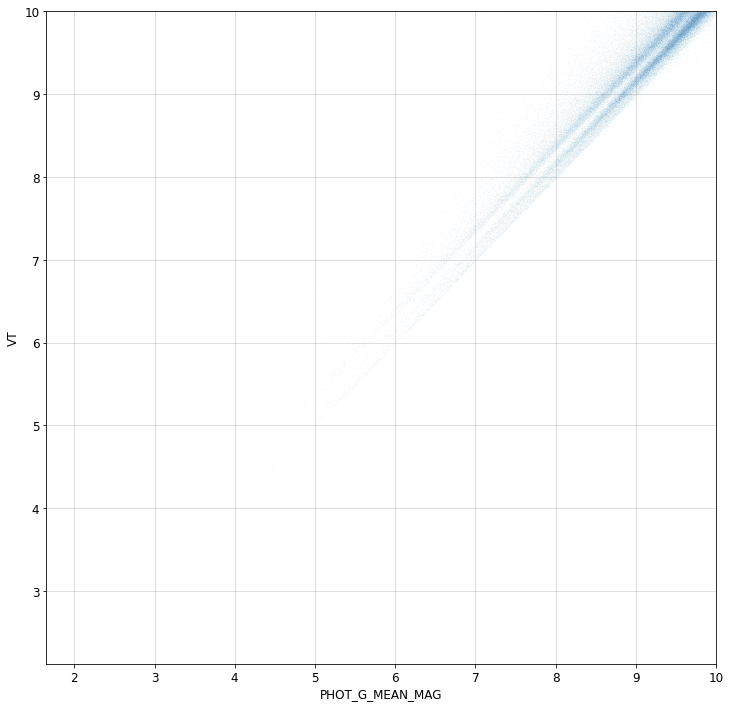

In [19]:
plt.figure(figsize=(12, 12))
plt.plot(gaia['PHOT_G_MEAN_MAG'], tycho2['VTmag'], '.', ms=0.1, alpha=0.1)
plt.xlabel('PHOT_G_MEAN_MAG')
plt.ylabel('VT')
plt.xlim(xmax=10)
plt.ylim(ymax=10)
plt.grid(alpha=0.5)
plt.show()

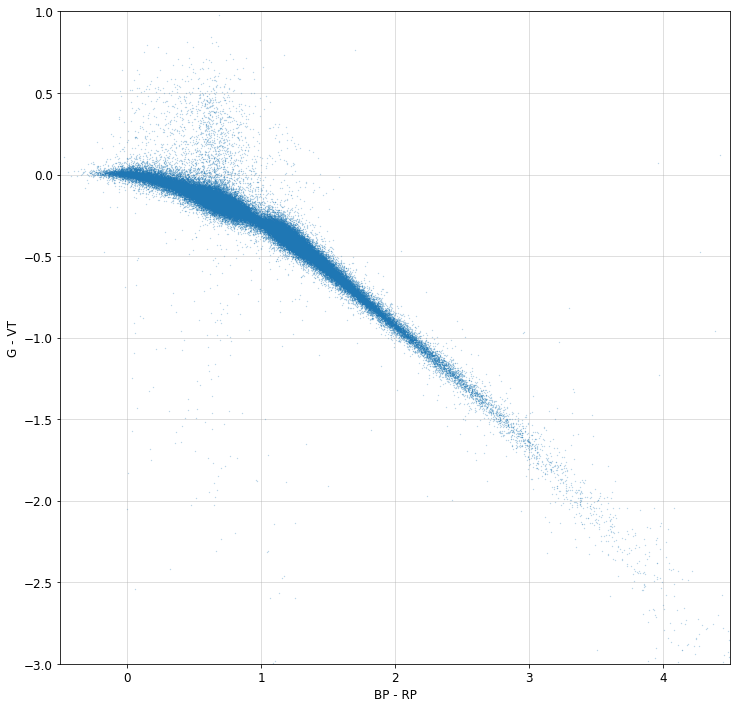

In [23]:
plt.figure(figsize=(12, 12))
plt.plot((gaia['PHOT_BP_MEAN_MAG']-gaia['PHOT_RP_MEAN_MAG']), (gaia['PHOT_G_MEAN_MAG']-tycho2['VTmag']), '.', ms=0.5, alpha=0.5)
plt.xlabel('BP - RP')
plt.ylabel('G - VT')
plt.grid(alpha=0.5)
plt.axis([-0.5, 4.5, -3, 1.])
plt.show()

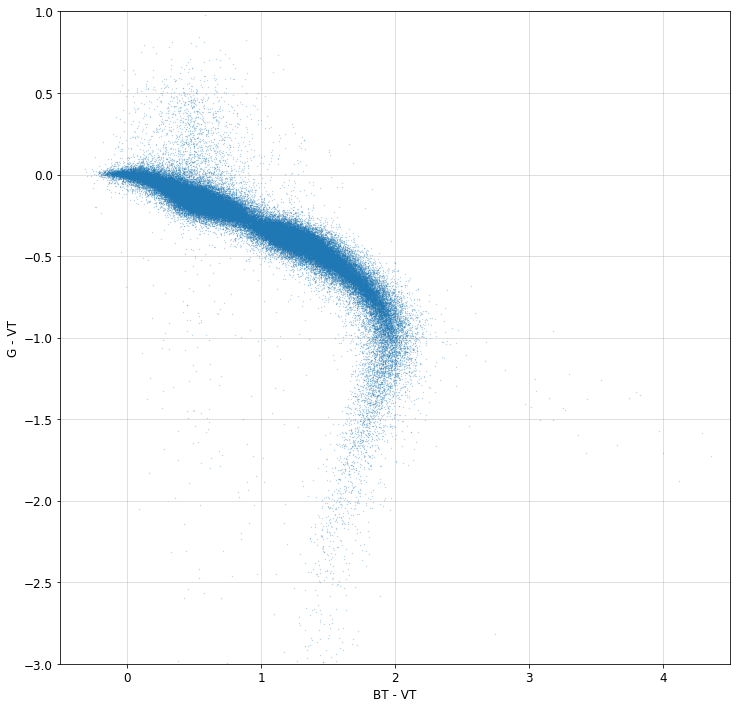

In [25]:
plt.figure(figsize=(12, 12))
plt.plot((tycho2['BTmag']-tycho2['VTmag']), (gaia['PHOT_G_MEAN_MAG']-tycho2['VTmag']), '.', ms=0.5, alpha=0.5)
plt.xlabel('BT - VT')
plt.ylabel('G - VT')
plt.grid(alpha=0.5)
plt.axis([-0.5, 4.5, -3, 1.])
plt.show()

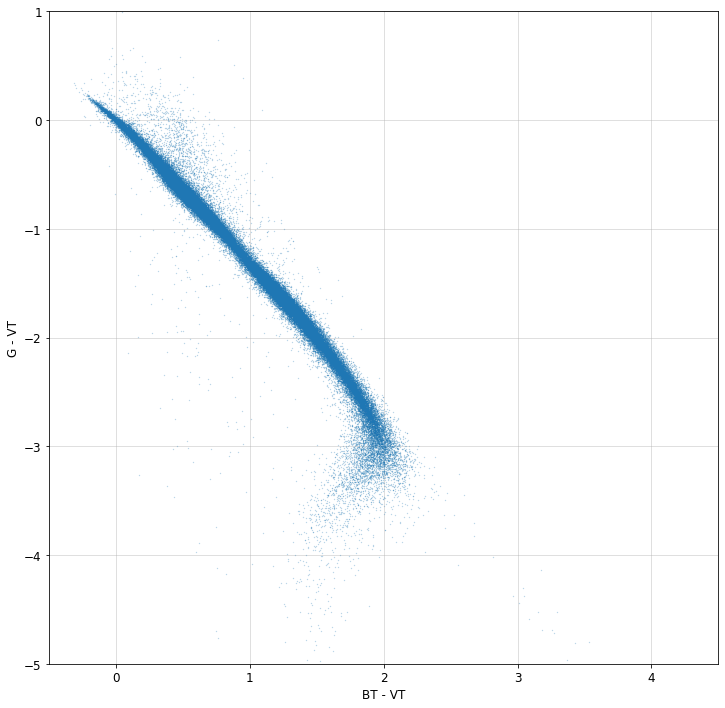

In [27]:
plt.figure(figsize=(12, 12))
plt.plot((tycho2['BTmag']-tycho2['VTmag']), (gaia['PHOT_G_MEAN_MAG']-tycho2['BTmag']), '.', ms=0.5, alpha=0.5)
plt.xlabel('BT - VT')
plt.ylabel('G - VT')
plt.grid(alpha=0.5)
plt.axis([-0.5, 4.5, -5, 1.])
plt.show()

In [ ]:
plt.figure(figsize=(12, 12))
plt.plot((tycho2['BTmag']-tycho2['VTmag']), (gaia['PHOT_G_MEAN_MAG']-tycho2['BTmag']), '.', ms=0.5, alpha=0.5)
plt.xlabel('BT - VT')
plt.ylabel('G - VT')
plt.grid(alpha=0.5)
plt.axis([-0.5, 4.5, -5, 1.])
plt.show()